## Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import wandb

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.constants import EMOTION_LABELS, NUM_CLASSES, IMAGE_SIZE
from src.dataset import FER2013Dataset
from src.train_utils import (
    set_seed,
    get_device,
    count_parameters,
    train_one_epoch,
    evaluate,
)

## Configuration

In [2]:
CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"

ENABLE_WANDB = True

IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

device = get_device()

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Data Loading

In [3]:
train_dataset = FER2013Dataset(CSV_PATH, split="Training")
val_dataset = FER2013Dataset(CSV_PATH, split="PublicTest")

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

image, label = train_dataset[0]
print("Single image shape:", image.shape)
print("Single label:", label.item())

Train samples: 28709
Validation samples: 3589
Single image shape: torch.Size([1, 48, 48])
Single label: 0


## TinyCNN Architecture

In [4]:
class TinyCNN(nn.Module):
    def __init__(self, dropout=0.0, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 48 -> 24

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 24 -> 12
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 12 * 12, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model Sanity Check

In [5]:
set_seed(42)

model = TinyCNN(dropout=0.0).to(device)

print(model)
print("Trainable parameters:", count_parameters(model))

sample_images, sample_labels = next(
    iter(DataLoader(train_dataset, batch_size=8, shuffle=True))
)

sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

criterion = nn.CrossEntropyLoss()

sample_outputs = model(sample_images)
sample_loss = criterion(sample_outputs, sample_labels)

model.zero_grad()
sample_loss.backward()

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Loss:", sample_loss.item())
print("Backward pass: OK")

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4608, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Trainable parameters: 595655
Input shape: torch.Size([8, 1, 48, 48])
Output shape: torch.Size([8, 7])
Loss: 1.9312126636505127
Backward pass: OK


## Helper: small subset

In [6]:
def make_small_subset(dataset, size=50, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=size, replace=False)
    return Subset(dataset, indices.tolist())

## Helper: plot history

In [7]:
def plot_history(history_df, run_name, sanity_check=False):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")

    if sanity_check:
        plt.plot(history_df["epoch"], history_df["small_data_loss"], label="Small Data Loss")
    else:
        plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{run_name}_loss.png", dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train Accuracy")

    if sanity_check:
        plt.plot(history_df["epoch"], history_df["small_data_accuracy"], label="Small Data Accuracy")
    else:
        plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{run_name} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"{run_name}_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

## Training function for one W&B run

In [8]:
def run_tiny_cnn_experiment(run_config):
    set_seed(run_config["seed"])

    run_name = run_config["run_name"]
    sanity_check = run_config["sanity_check"]

    if sanity_check:
        small_dataset = make_small_subset(
            train_dataset,
            size=run_config["small_data_size"],
            seed=run_config["seed"],
        )

        train_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            val_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    model = TinyCNN(dropout=run_config["dropout"]).to(device)

    num_parameters = count_parameters(model)

    run_config["num_parameters"] = num_parameters
    run_config["device"] = device

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=run_config["learning_rate"],
        weight_decay=run_config["weight_decay"],
    )

    run = None

    if ENABLE_WANDB:
        run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name=run_name,
            config=run_config,
        )

    history = []

    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    best_small_data_accuracy = 0.0

    final_labels = None
    final_preds = None

    for epoch in range(1, run_config["epochs"] + 1):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        eval_loss, eval_metrics, eval_labels, eval_preds = evaluate(
            model,
            eval_loader,
            criterion,
            device,
        )

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
        }

        if sanity_check:
            best_small_data_accuracy = max(
                best_small_data_accuracy,
                eval_metrics["accuracy"],
            )

            row.update({
                "small_data_loss": eval_loss,
                "small_data_accuracy": eval_metrics["accuracy"],
                "small_data_macro_f1": eval_metrics["macro_f1"],
                "best_small_data_accuracy": best_small_data_accuracy,
            })

            print(
                f"{run_name} | Epoch {epoch:02d}/{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"small_loss={eval_loss:.4f} "
                f"small_acc={eval_metrics['accuracy']:.4f}"
            )

        else:
            best_val_accuracy = max(best_val_accuracy, eval_metrics["accuracy"])
            best_val_macro_f1 = max(best_val_macro_f1, eval_metrics["macro_f1"])

            row.update({
                "val_loss": eval_loss,
                "val_accuracy": eval_metrics["accuracy"],
                "val_macro_f1": eval_metrics["macro_f1"],
                "best_val_accuracy": best_val_accuracy,
                "best_val_macro_f1": best_val_macro_f1,
            })

            print(
                f"{run_name} | Epoch {epoch:02d}/{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} "
                f"train_f1={train_metrics['macro_f1']:.4f} | "
                f"val_loss={eval_loss:.4f} "
                f"val_acc={eval_metrics['accuracy']:.4f} "
                f"val_f1={eval_metrics['macro_f1']:.4f}"
            )

        history.append(row)

        if ENABLE_WANDB:
            wandb.log(row, step=epoch)

        final_labels = eval_labels
        final_preds = eval_preds

    history_df = pd.DataFrame(history)

    plot_history(history_df, run_name, sanity_check=sanity_check)

    if ENABLE_WANDB:
        if not sanity_check:
            class_names = [EMOTION_LABELS[i] for i in range(NUM_CLASSES)]

            wandb.log({
                "validation_confusion_matrix": wandb.plot.confusion_matrix(
                    y_true=final_labels,
                    preds=final_preds,
                    class_names=class_names,
                )
            })

            run.summary["best_val_accuracy"] = best_val_accuracy
            run.summary["best_val_macro_f1"] = best_val_macro_f1

        else:
            run.summary["best_small_data_accuracy"] = best_small_data_accuracy

        run.summary["num_parameters"] = num_parameters
        run.finish()

    if sanity_check:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type": run_config["experiment_type"],
            "num_parameters": num_parameters,
            "best_small_data_accuracy": best_small_data_accuracy,
        }
    else:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type": run_config["experiment_type"],
            "num_parameters": num_parameters,
            "best_val_accuracy": best_val_accuracy,
            "best_val_macro_f1": best_val_macro_f1,
        }

    return result, history_df

## TinyCNN Run Configs

In [9]:
BASE_CONFIG = {
    "dataset": "FER2013",
    "model_name": "tiny_cnn",
    "architecture_type": "cnn",
    "input_shape": "1x48x48",
    "normalization": "training_mean_std",
    "optimizer": "Adam",
    "seed": 42,
    "train_split": "Training",
    "val_split": "PublicTest",
}

In [10]:
TINY_CNN_RUNS = [
    {
        **BASE_CONFIG,
        "run_name": "run_01_tiny_cnn_small50_overfit",
        "experiment_type": "small_data_overfit_sanity_check",
        "sanity_check": True,
        "small_data_size": 50,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 10,
        "epochs": 50,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_02_tiny_cnn_baseline",
        "experiment_type": "baseline",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 12,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_03_tiny_cnn_lr_3e_4",
        "experiment_type": "learning_rate_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 3e-4,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 12,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_04_tiny_cnn_lr_3e_3",
        "experiment_type": "learning_rate_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.0,
        "learning_rate": 3e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 12,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_05_tiny_cnn_dropout_0_3",
        "experiment_type": "dropout_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 12,
    },
]

# Now run leftover models
TINY_CNN_RUNS = TINY_CNN_RUNS[1:]

## Run all TinyCNN Experiments

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


run_05_tiny_cnn_dropout_0_3 | Epoch 01/12 | train_loss=1.6272 train_acc=0.3588 train_f1=0.2645 | val_loss=1.4590 val_acc=0.4341 val_f1=0.3316


run_05_tiny_cnn_dropout_0_3 | Epoch 02/12 | train_loss=1.4241 train_acc=0.4533 train_f1=0.3647 | val_loss=1.3596 val_acc=0.4751 val_f1=0.3750


run_05_tiny_cnn_dropout_0_3 | Epoch 03/12 | train_loss=1.3212 train_acc=0.4952 train_f1=0.4110 | val_loss=1.3049 val_acc=0.4990 val_f1=0.4085


run_05_tiny_cnn_dropout_0_3 | Epoch 04/12 | train_loss=1.2405 train_acc=0.5261 train_f1=0.4526 | val_loss=1.2763 val_acc=0.5004 val_f1=0.4220


...

run_05_tiny_cnn_dropout_0_3 | Epoch 08/12 | train_loss=0.9678 train_acc=0.6276 train_f1=0.6011 | val_loss=1.2755 val_acc=0.5327 val_f1=0.4987


run_05_tiny_cnn_dropout_0_3 | Epoch 09/12 | train_loss=0.9065 train_acc=0.6543 train_f1=0.6300 | val_loss=1.3485 val_acc=0.5277 val_f1=0.4885


run_05_tiny_cnn_dropout_0_3 | Epoch 10/12 | train_loss=0.8516 train_acc=0.6742 train_f1=0.6491 | val_loss=1.3657 val_acc=0.5369 val_f1=0.4996


run_05_tiny_cnn_dropout_0_3 | Epoch 11/12 | train_loss=0.7880 train_acc=0.6971 train_f1=0.6788 | val_loss=1.4207 val_acc=0.5255 val_f1=0.4955


run_05_tiny_cnn_dropout_0_3 | Epoch 12/12 | train_loss=0.7337 train_acc=0.7188 train_f1=0.7058 | val_loss=1.4036 val_acc=0.5322 val_f1=0.5113


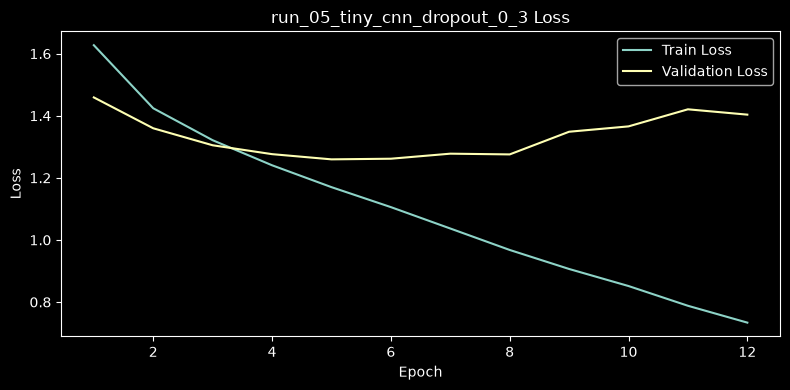

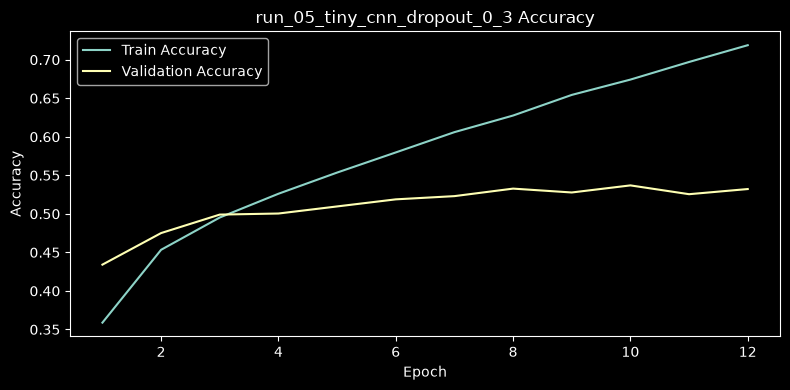

best_val_accuracy,▁▄▅▆▆▇▇█████
best_val_macro_f1,▁▃▄▅▆▆▇█████
epoch,▁▂▂▃▄▄▅▅▆▇▇█
train_accuracy,▁▃▄▄▅▅▆▆▇▇██
train_loss,█▆▆▅▄▄▃▃▂▂▁▁
train_macro_f1,▁▃▃▄▅▅▆▆▇▇██
val_accuracy,▁▄▅▆▆▇▇█▇█▇█
val_loss,█▅▃▂▁▁▂▂▄▅▇▆
val_macro_f1,▁▃▄▅▆▆▇█▇█▇█
best_val_accuracy,0.53692
best_val_macro_f1,0.51132


,run_name,model,experiment_type,num_parameters,best_val_accuracy,best_val_macro_f1
0,run_05_tiny_cnn_dropout_0_3,tiny_cnn,dropout_test,595655,0.536918,0.511325


In [11]:
tiny_cnn_results = []
tiny_cnn_histories = {}

for run_config in TINY_CNN_RUNS:
    result, history_df = run_tiny_cnn_experiment(run_config)

    tiny_cnn_results.append(result)
    tiny_cnn_histories[run_config["run_name"]] = history_df

tiny_cnn_results_df = pd.DataFrame(tiny_cnn_results)
tiny_cnn_results_df